### SKEWNESS STRAT (yfinance version)

Single-notebook replication of the source cross-asset skew strategy with Yahoo Finance data.


In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf
from matplotlib import pyplot as plt
from scipy.stats import norm
import statsmodels.api as sm
import logging

In [2]:
# Clean the DataFrame and calculate necessary fields
def clean(df, ticker):
    cols = ["Date", "Ticker", "close", "open", "NextOpen", "LogReturn"]
    if df is None or df.empty:
        return pd.DataFrame(columns=cols)

    data = df.copy()
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = [c[0] if isinstance(c, tuple) else c for c in data.columns]

    data = data.reset_index()
    if "Date" not in data.columns and "Datetime" in data.columns:
        data = data.rename(columns={"Datetime": "Date"})

    if "Date" not in data.columns or "Open" not in data.columns:
        return pd.DataFrame(columns=cols)

    close_col = "Adj Close" if "Adj Close" in data.columns else ("Close" if "Close" in data.columns else None)
    if close_col is None:
        return pd.DataFrame(columns=cols)

    data["Date"] = pd.to_datetime(data["Date"]).dt.date
    data["Ticker"] = ticker
    data["close"] = pd.to_numeric(data[close_col], errors="coerce")
    data["open"] = pd.to_numeric(data["Open"], errors="coerce")

    data = data.sort_values("Date").drop_duplicates(subset=["Date"], keep="last")
    data["NextOpen"] = data["open"].shift(-1)
    data["LogReturn"] = np.log(data["close"] / data["close"].shift(1))

    return data[cols].dropna(subset=["close", "open"]).reset_index(drop=True)


def load(etf):
    end_date = dt.datetime.now()
    start_date = end_date - dt.timedelta(days=3650)  # 10 years

    try:
        raw = yf.download(
            etf,
            start=start_date.date(),
            end=end_date.date(),
            interval="1d",
            auto_adjust=False,
            progress=False,
            threads=False,
        )
        return clean(raw, etf)
    except Exception as e:
        logging.error(f"Unexpected error for {etf}: {e}")
        raise



In [3]:
# Example usage:
spy = load('SPY')
print(spy.head())

         Date Ticker       close        open    NextOpen  LogReturn
0  2016-03-24    SPY  172.568619  202.000000  203.610001        NaN
1  2016-03-28    SPY  172.670563  203.610001  202.759995   0.000591
2  2016-03-29    SPY  174.267807  202.759995  206.300003   0.009208
3  2016-03-30    SPY  175.032410  206.300003  205.910004   0.004378
4  2016-03-31    SPY  174.607666  205.910004  204.350006  -0.002430


In [4]:
# Calculate the rolling mean and rolling standard deviation of LogReturn
spy['Avg'] = spy['LogReturn'].rolling(window=256).mean()
spy['Dev'] = spy['LogReturn'].rolling(window=256).std()

# Calculate the daily skewness component
spy['SkewDay'] = ((spy['LogReturn'] - spy['Avg']) / spy['Dev']) ** 3

# Calculate the rolling mean of the daily skewness component to get Skew
spy['Skew'] = spy['SkewDay'].rolling(window=256).mean()

# Drop rows where Skew is NaN
spy = spy.dropna(subset=['Skew'])

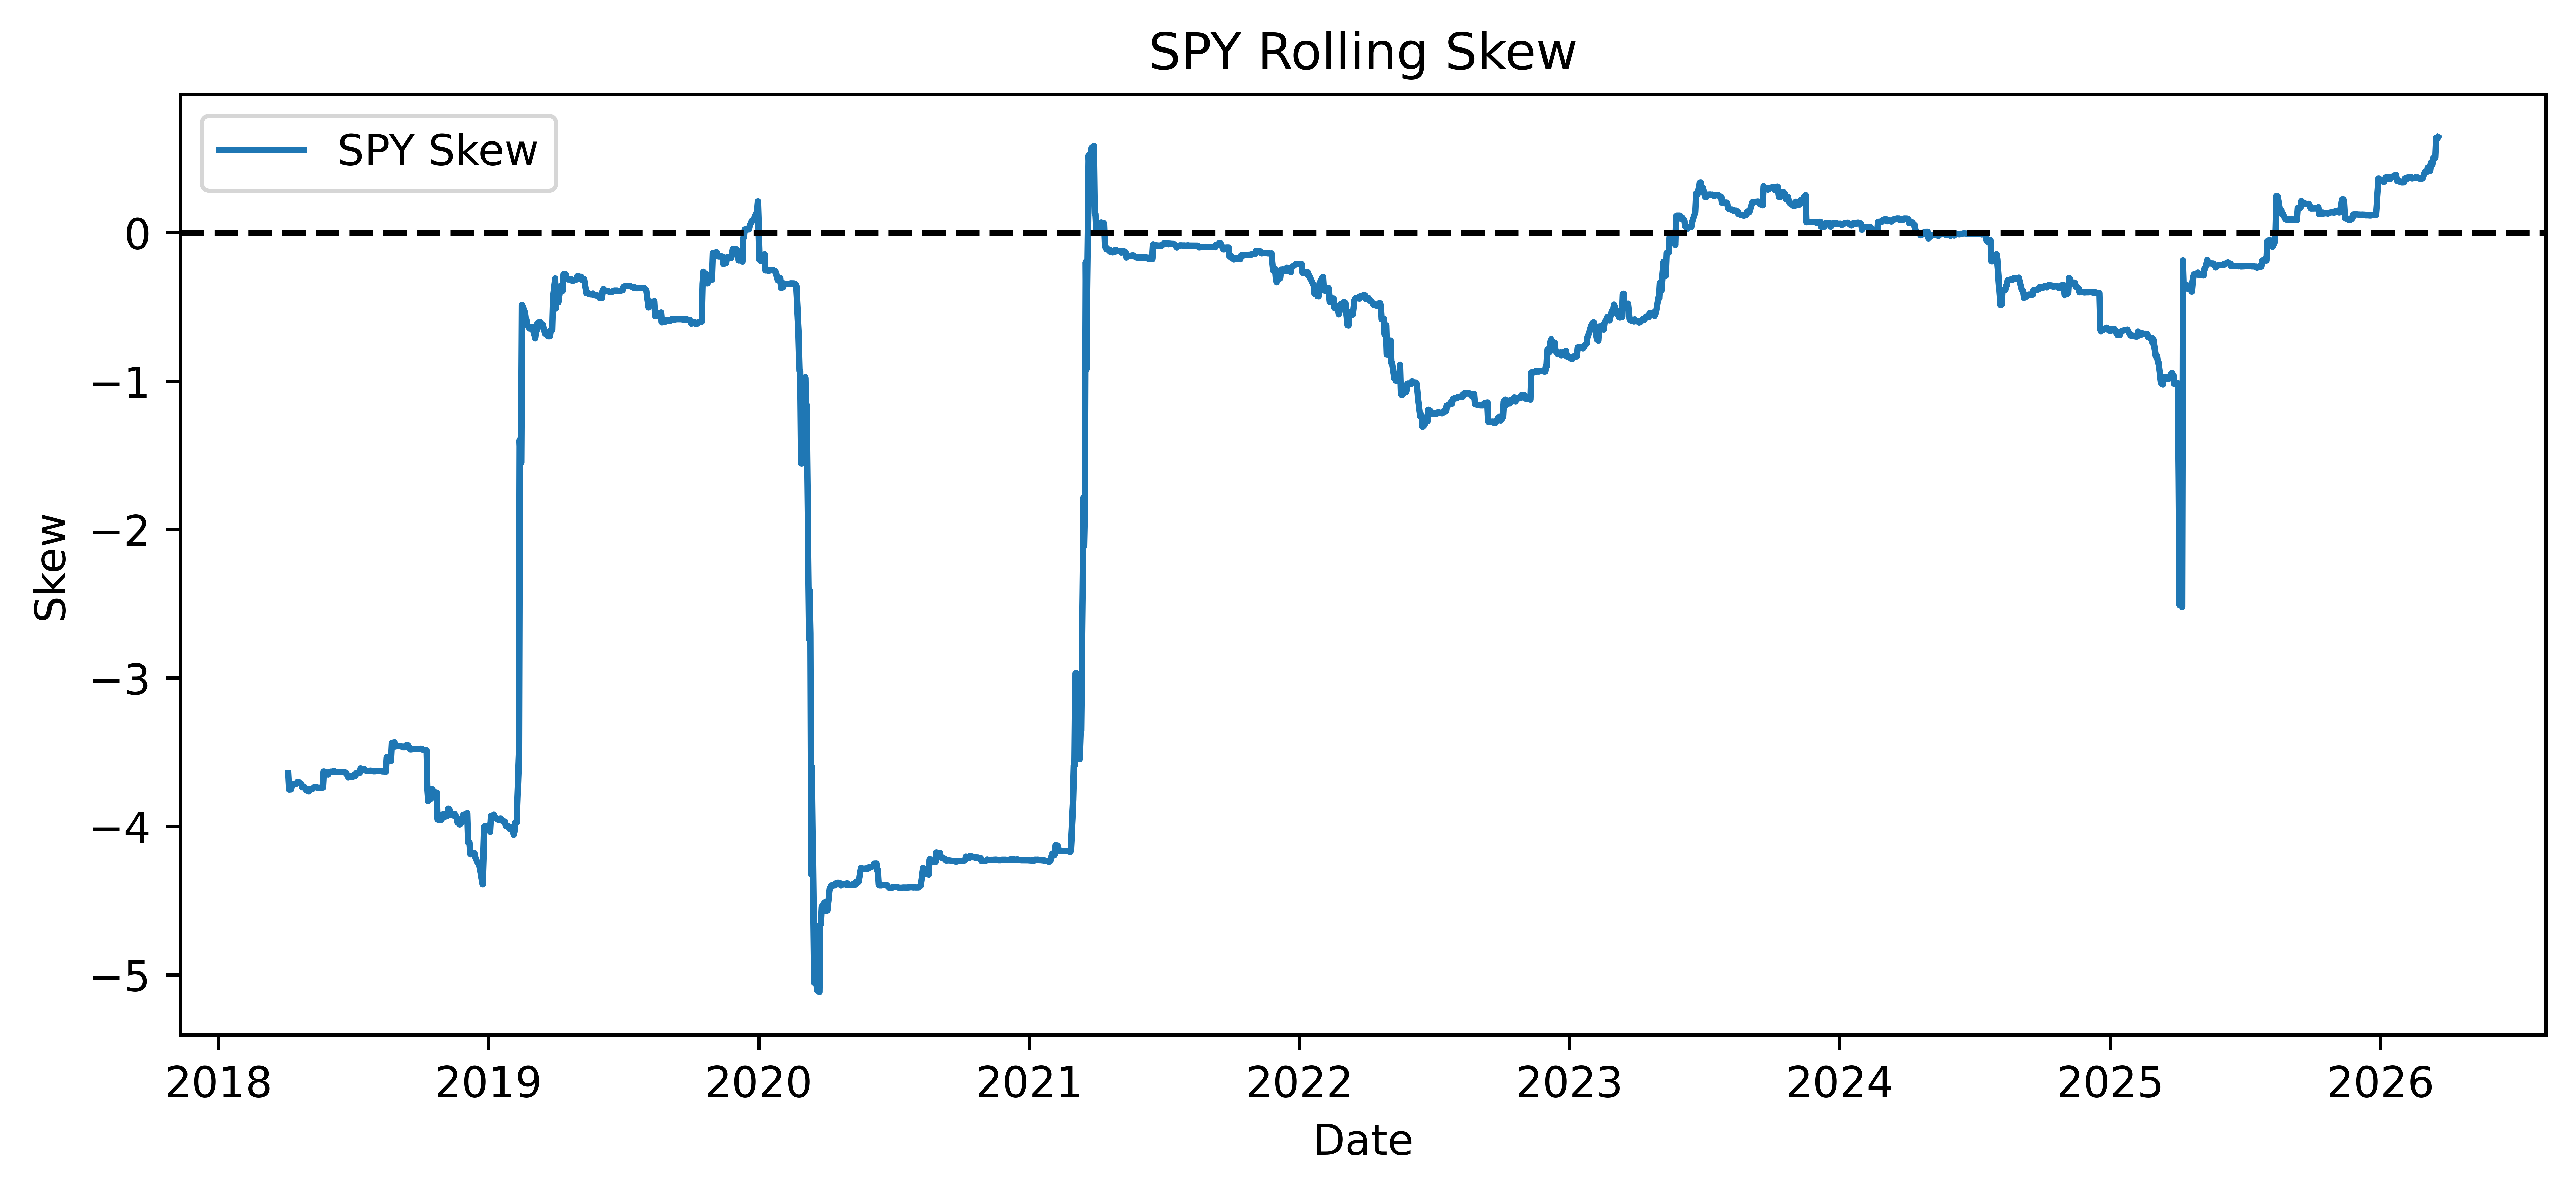

In [5]:
# Plot the results
plt.figure(figsize=(10, 4), dpi=900)
plt.plot(spy['Date'], spy['Skew'], label="SPY Skew")
plt.axhline(y=0, color='black', linestyle='--', label=None)
plt.xlabel("Date")
plt.ylabel("Skew")
plt.title("SPY Rolling Skew")
plt.legend()
plt.show()

It’s jumpy, but the jumps make sense as it’s a third power calculation, so large values will be amplified. SPY became very negatively skewed over COVID-19 as there were all the market corrections leading to large down days. In recent days it’s now more positively skewed as we’ve seen some larger positive returns.

In [6]:
# Define the universe of assets
universe = [
    ("Equity", ["SPY", "EWU", "EWJ", "INDA", "EWG", "EWL", "EWP", "EWQ", 
                "VTI", "FXI", "EWZ", "EWY", "EWA", "EWC", "EWG",
                "EWH", "EWI", "EWN", "EWD", "EWT", "EZA", "EWW", "ENOR", "EDEN", "TUR"]),
    ("FI", ["AGG", "TLT", "LQD", "JNK", "MUB", "MBB", "IAGG", "IGOV", "EMB", 
            "BND", "BNDX", "VCIT", "VCSH", "BSV", "SRLN"]),
    ("Commodities", ["GLD", "SLV", "GSG", "USO", "PPLT", "UNG", "DBA"]),
    ("Other", ["IYR", "REET", "USRT", "ICF", "VNQ"]),
    ("Ccy", ["UUP", "FXY", "FXE", "FXF", "FXB", "FXA", "FXC"])
]

In [7]:
results = {}

for category, tickers in universe:
    category_results = {}
    for ticker in tickers:
        try:
            # Load the ETF data
            df = load(ticker)
            
            # Calculate rolling mean and stddev for LogReturn
            df['Avg'] = df['LogReturn'].rolling(window=256).mean()
            df['Dev'] = df['LogReturn'].rolling(window=256).std()

            # Calculate skewness
            df['SkewDay'] = ((df['LogReturn'] - df['Avg']) / df['Dev']) ** 3
            df['Skew'] = df['SkewDay'].rolling(window=256).mean()

            # Drop NaN values
            df = df.dropna(subset=['Skew'])

            # Store the result
            category_results[ticker] = df

        except Exception as e:
            print(f"Error processing {ticker}: {e}")
    
    results[category] = category_results

# Example: Access SPY data
spy_data = results['Equity']['SPY']
print(spy_data.head())

           Date Ticker       close        open    NextOpen  LogReturn  \
511  2018-04-05    SPY  234.743637  265.549988  263.420013   0.007861   
512  2018-04-06    SPY  229.512207  263.420013  261.369995  -0.022538   
513  2018-04-09    SPY  230.643311  261.369995  264.269989   0.004916   
514  2018-04-10    SPY  234.310669  264.269989  263.470001   0.015775   
515  2018-04-11    SPY  233.082382  263.470001  265.260010  -0.005256   

          Avg       Dev    SkewDay      Skew  
511  0.000544  0.007386   0.972098 -3.639606  
512  0.000443  0.007524 -28.493565 -3.751157  
513  0.000471  0.007527   0.205884 -3.749934  
514  0.000540  0.007586   8.099629 -3.718087  
515  0.000517  0.007595  -0.439106 -3.719802  


In [8]:
# Initialize an empty list to hold the data for all asset classes
all_data_raw = []

# Iterate over the universe to load data for each asset class and its ETFs
for asset_class, etfs in universe:
    print(asset_class)
    
    # Initialize a list to hold DataFrames for each ETF in the asset class
    resdf = []
    
    for etf in etfs:
        # Load data for the ETF
        df = load(etf)
        
        # Append the DataFrame to the list
        resdf.append(df)
    
    # Concatenate all DataFrames in resdf into a single DataFrame for the asset class
    resdf_c = pd.concat(resdf, ignore_index=True)
    
    # Add a new column to indicate the asset class
    resdf_c['AssetClass'] = asset_class
    
    # Append the resulting DataFrame to all_data_raw
    all_data_raw.append(resdf_c)

# Concatenate all asset class DataFrames into a single DataFrame
all_data = pd.concat(all_data_raw, ignore_index=True)

Equity
FI
Commodities
Other
Ccy


In [9]:
# Stable rolling feature construction by ticker (preserves columns)
all_data = all_data.sort_values(['Ticker', 'Date']).reset_index(drop=True)

grp = all_data.groupby('Ticker', sort=False)['LogReturn']
all_data['Avg'] = grp.transform(lambda s: s.rolling(window=256, min_periods=256).mean())
all_data['Dev'] = grp.transform(lambda s: s.rolling(window=256, min_periods=256).std())
all_data['SkewDay'] = ((all_data['LogReturn'] - all_data['Avg']) / all_data['Dev']) ** 3
all_data['Skew'] = all_data.groupby('Ticker', sort=False)['SkewDay'].transform(
    lambda s: s.rolling(window=256, min_periods=256).mean()
)

all_data = all_data.dropna(subset=['Skew']).reset_index(drop=True)

if 'Ticker' not in all_data.columns:
    raise RuntimeError(f"Ticker column missing after skew construction. Columns={list(all_data.columns)}")



logging + check (returns and skew)

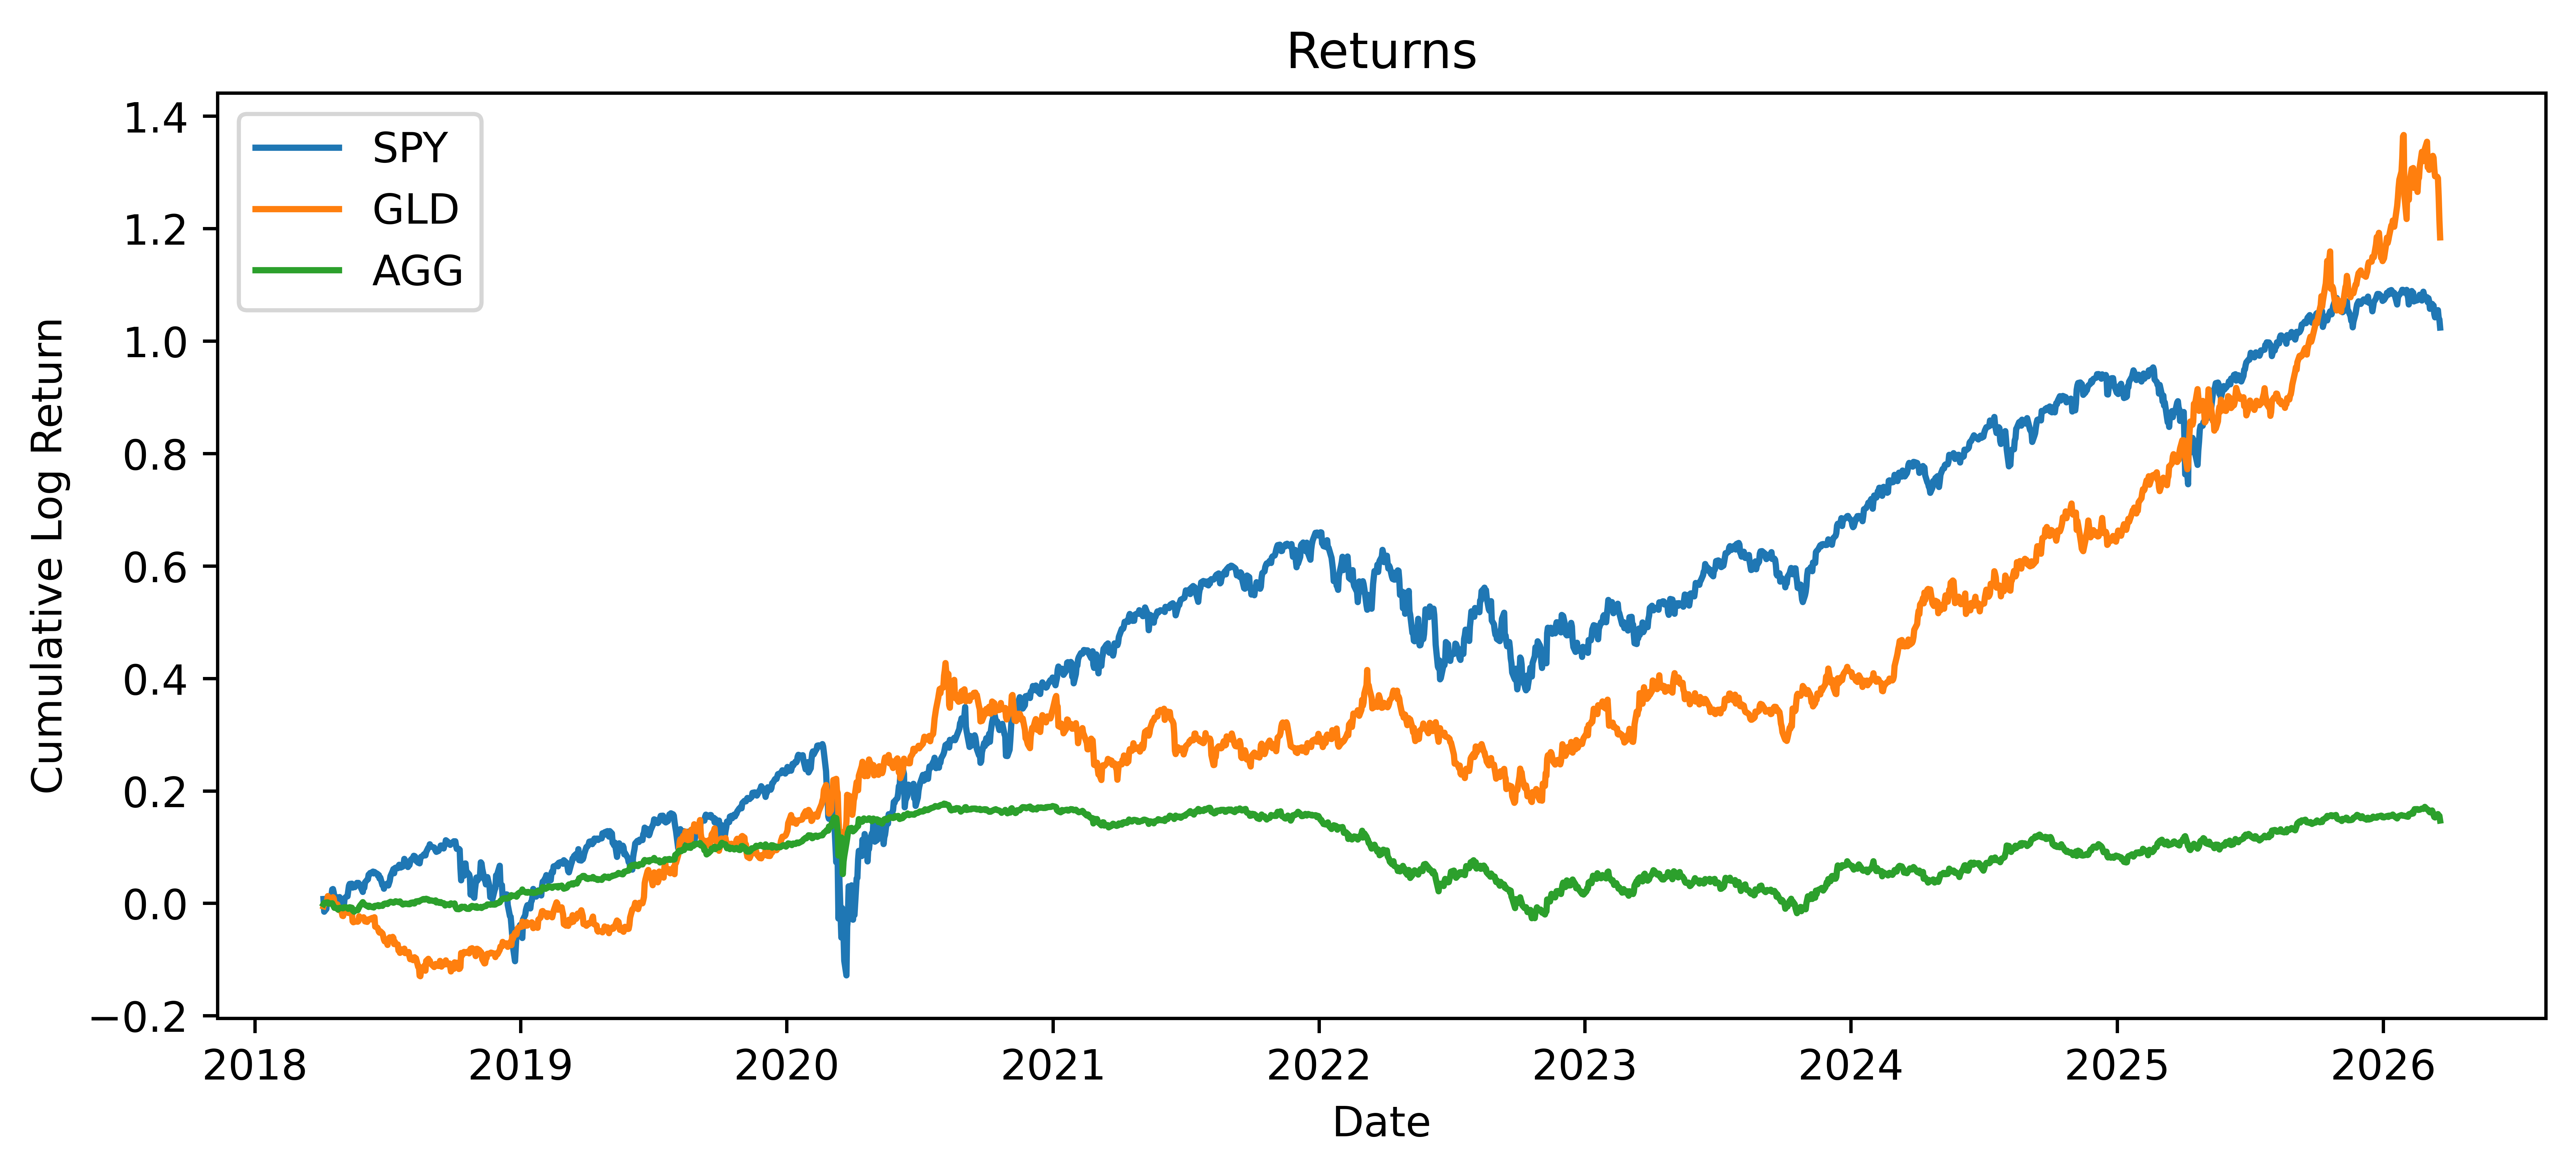

In [10]:
# Filter the data for SPY, GLD, and AGG
spy_data = all_data[all_data['Ticker'] == "SPY"]
gld_data = all_data[all_data['Ticker'] == "GLD"]
agg_data = all_data[all_data['Ticker'] == "AGG"]

# Plot cumulative sum of LogReturn for SPY
plt.figure(figsize=(10, 4), dpi=900)
plt.plot(spy_data['Date'], spy_data['LogReturn'].cumsum(), label="SPY")

# Plot cumulative sum of LogReturn for GLD
plt.plot(gld_data['Date'], gld_data['LogReturn'].cumsum(), label="GLD")

# Plot cumulative sum of LogReturn for AGG
plt.plot(agg_data['Date'], agg_data['LogReturn'].cumsum(), label="AGG")

# Add title and labels
plt.title("Returns")
plt.xlabel("Date")
plt.ylabel("Cumulative Log Return")

# Display the legend
plt.legend()

# Show the plot
plt.show()

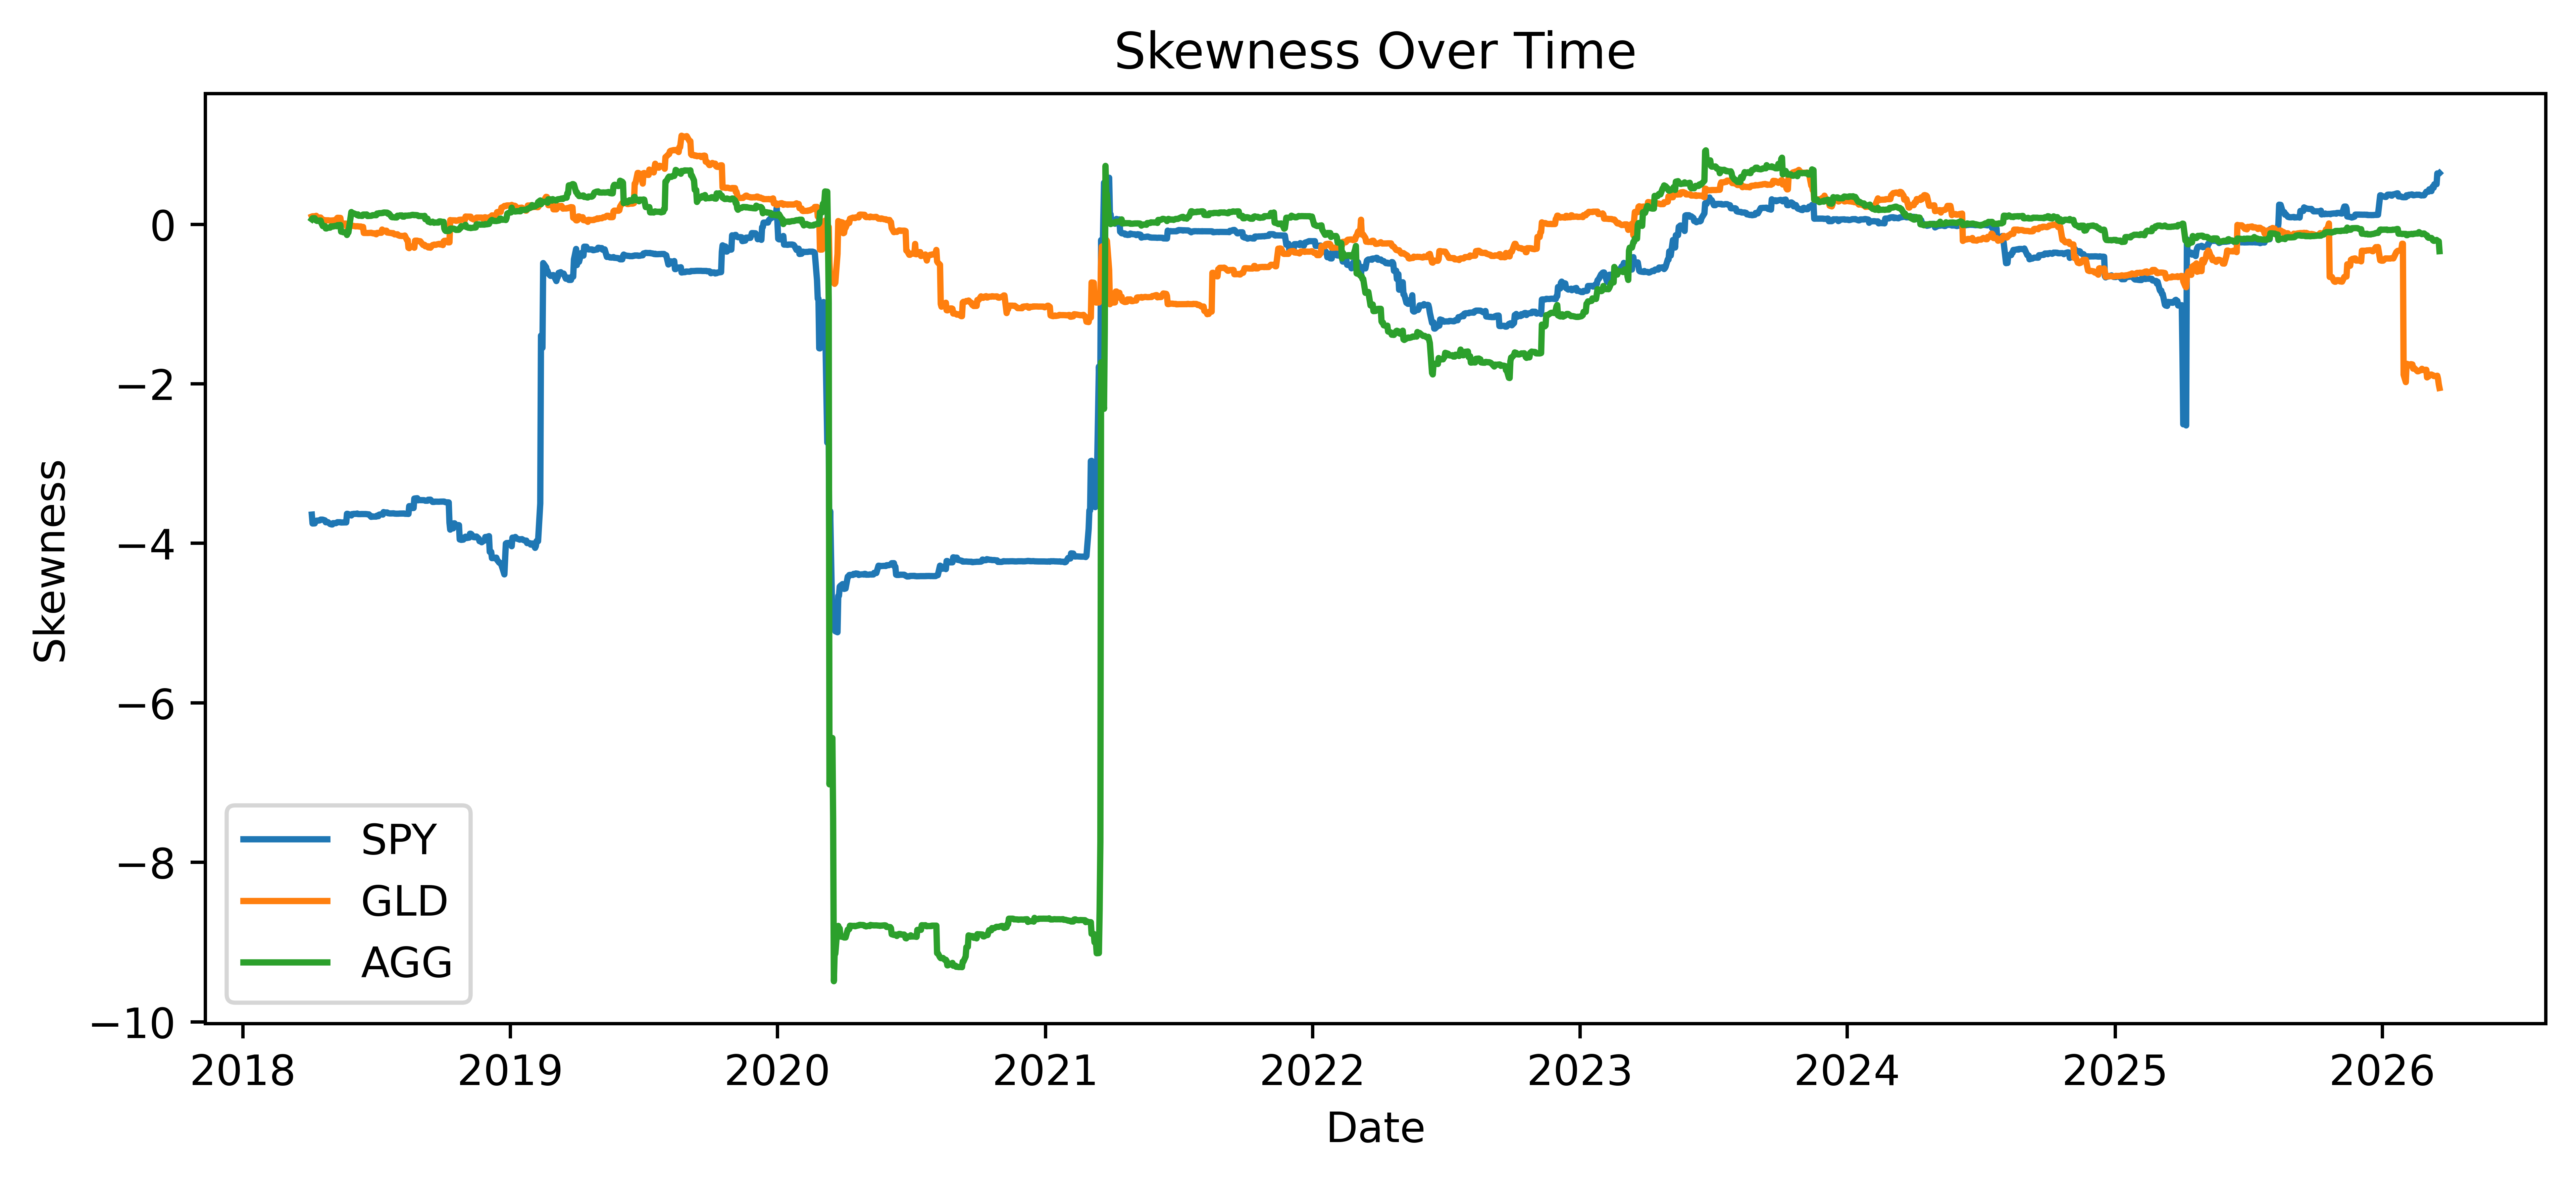

In [11]:
# Filter the data for SPY, GLD, and AGG
spy_data = all_data[all_data['Ticker'] == "SPY"]
gld_data = all_data[all_data['Ticker'] == "GLD"]
agg_data = all_data[all_data['Ticker'] == "AGG"]

# Plot skewness for SPY
plt.figure(figsize=(10, 4), dpi=900)
plt.plot(spy_data['Date'], spy_data['Skew'], label="SPY")

# Plot skewness for GLD
plt.plot(gld_data['Date'], gld_data['Skew'], label="GLD")

# Plot skewness for AGG
plt.plot(agg_data['Date'], agg_data['Skew'], label="AGG")

# Add title and labels
plt.title("Skewness Over Time")
plt.xlabel("Date")
plt.ylabel("Skewness")

# Display the legend
plt.legend()

# Show the plot
plt.show()

### building the backtest

In [12]:
# Ensure the 'Date' column is in datetime format
all_data['Date'] = pd.to_datetime(all_data['Date'])

# Add 'Month' and 'Week' columns by flooring the 'Date' to the beginning of the respective periods
all_data['Month'] = all_data['Date'].dt.to_period('M').dt.to_timestamp()
all_data['Week'] = all_data['Date'].dt.to_period('W-SUN').dt.to_timestamp()

# Calculate the next trading day for each ticker
all_data['NextDay'] = all_data.groupby('Ticker')['Date'].shift(-1)

# Set a placeholder date far in the future to fill in the last 'NextDay' entry for each group (similar to Date(2015) in Julia)
future_date = pd.Timestamp('2015-01-01')
all_data['NextDay'].fillna(future_date, inplace=True)

# Group by Month, AssetClass, and Ticker to get the end-of-month values
monthly_vals = all_data.groupby(['Month', 'AssetClass', 'Ticker']).agg(
    Date=('Date', 'last'),         # Get the last date of the month
    NextDate=('NextDay', 'last'),  # Get the first trading day of the next month
    EOMSkew=('Skew', 'last')       # Get the last skew value of the month
).reset_index()

/var/folders/xg/dhj8tpr14lqgyb0stf1z1sm40000gn/T/ipykernel_81016/3656458114.py:13: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  all_data['NextDay'].fillna(future_date, inplace=True)


In [13]:
monthly_vals.head()

,Month,AssetClass,Ticker,Date,NextDate,EOMSkew
0,2017-03-01,Equity,EWG,2017-03-31,2017-04-03,0.132429
1,2017-04-01,Equity,EWG,2017-04-28,2017-05-01,1.865210
2,2017-05-01,Equity,EWG,2017-05-31,2017-06-01,1.883240
3,2017-06-01,Equity,EWG,2017-06-30,2017-07-03,1.629278
4,2017-07-01,Equity,EWG,2017-07-31,2017-08-01,1.517985


In [14]:
# Group by Date and AssetClass to rank assets within each group
monthly_vals['SkewWeightRaw'] = monthly_vals.groupby(['Date', 'AssetClass'])['EOMSkew'].transform(
    lambda x: x.rank(ascending=False) - ((len(x) + 1) / 2)
)

# Normalize the SkewWeightRaw to get SkewWeight (so that long positions sum to 1 and short positions sum to -1)
def normalize_weights(x):
    max_weight = x['SkewWeightRaw'].abs().max()
    return x['SkewWeightRaw'] / (x['SkewWeightRaw'].abs().sum() / 2)

monthly_vals['SkewWeight'] = monthly_vals.groupby(['Date', 'AssetClass']).apply(normalize_weights).reset_index(drop=True)

monthly_vals.head()

,Month,AssetClass,Ticker,Date,NextDate,EOMSkew,SkewWeightRaw,SkewWeight
0,2017-03-01,Equity,EWG,2017-03-31,2017-04-03,0.132429,0.0,NaN
1,2017-04-01,Equity,EWG,2017-04-28,2017-05-01,1.865210,0.0,NaN
2,2017-05-01,Equity,EWG,2017-05-31,2017-06-01,1.883240,0.0,NaN
3,2017-06-01,Equity,EWG,2017-06-30,2017-07-03,1.629278,0.0,NaN
4,2017-07-01,Equity,EWG,2017-07-31,2017-08-01,1.517985,0.0,NaN


Commodity ETFs - Latest Skew Values and Portfolio Weights
     Ticker   EOMSkew  SkewWeight
5530    DBA -0.034866   -0.166667
5531    GLD -2.051910    0.166667
5532    GSG  0.095486   -0.333333
5533   PPLT -2.374060    0.333333
5534    SLV -5.567510    0.500000
5535    UNG -0.828201    0.000000
5536    USO  0.697800   -0.500000


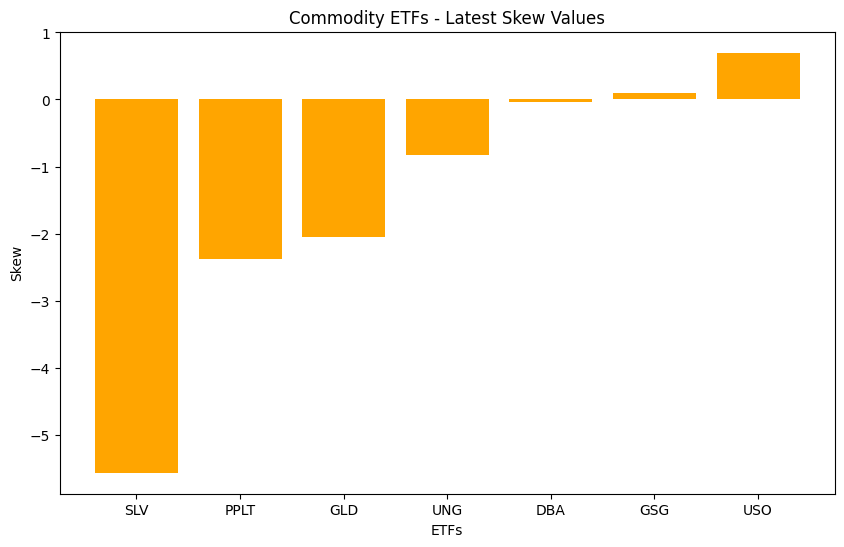

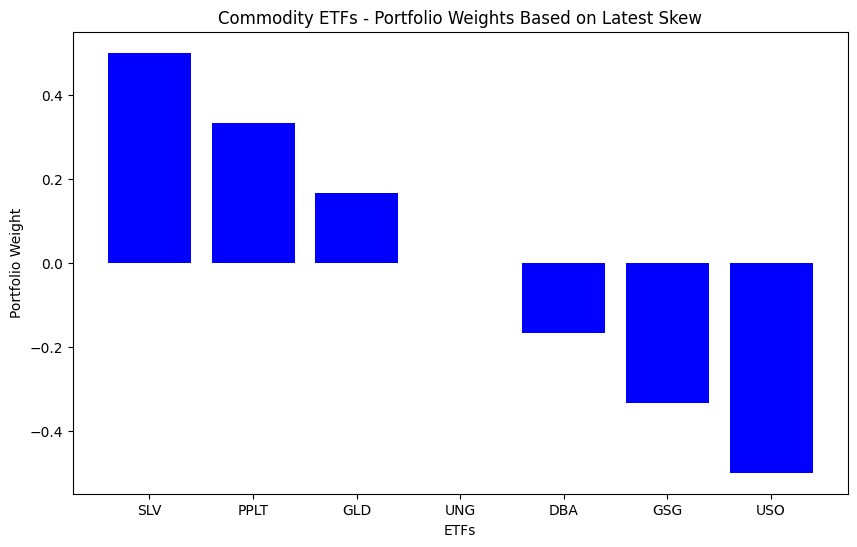

In [15]:
# Filter the data to get the latest skew values for Commodity ETFs
latest_date = monthly_vals['Date'].max()
commodity_etfs = monthly_vals[(monthly_vals['AssetClass'] == 'Commodities') & (monthly_vals['Date'] == latest_date)]

# Display the latest skew values and corresponding portfolio weights
print("Commodity ETFs - Latest Skew Values and Portfolio Weights")
print(commodity_etfs[['Ticker', 'EOMSkew', 'SkewWeight']])

# Visualize the relationship between skew values and portfolio weights
commodity_etfs_sorted = commodity_etfs.sort_values('EOMSkew')

# Plot Skew values
plt.figure(figsize=(10, 6))
plt.bar(commodity_etfs_sorted['Ticker'], commodity_etfs_sorted['EOMSkew'], color='orange')
plt.title('Commodity ETFs - Latest Skew Values')
plt.xlabel('ETFs')
plt.ylabel('Skew')
plt.show()

# Plot Portfolio Weights
plt.figure(figsize=(10, 6))
plt.bar(commodity_etfs_sorted['Ticker'], commodity_etfs_sorted['SkewWeight'], color='blue')
plt.title('Commodity ETFs - Portfolio Weights Based on Latest Skew')
plt.xlabel('ETFs')
plt.ylabel('Portfolio Weight')
plt.show()

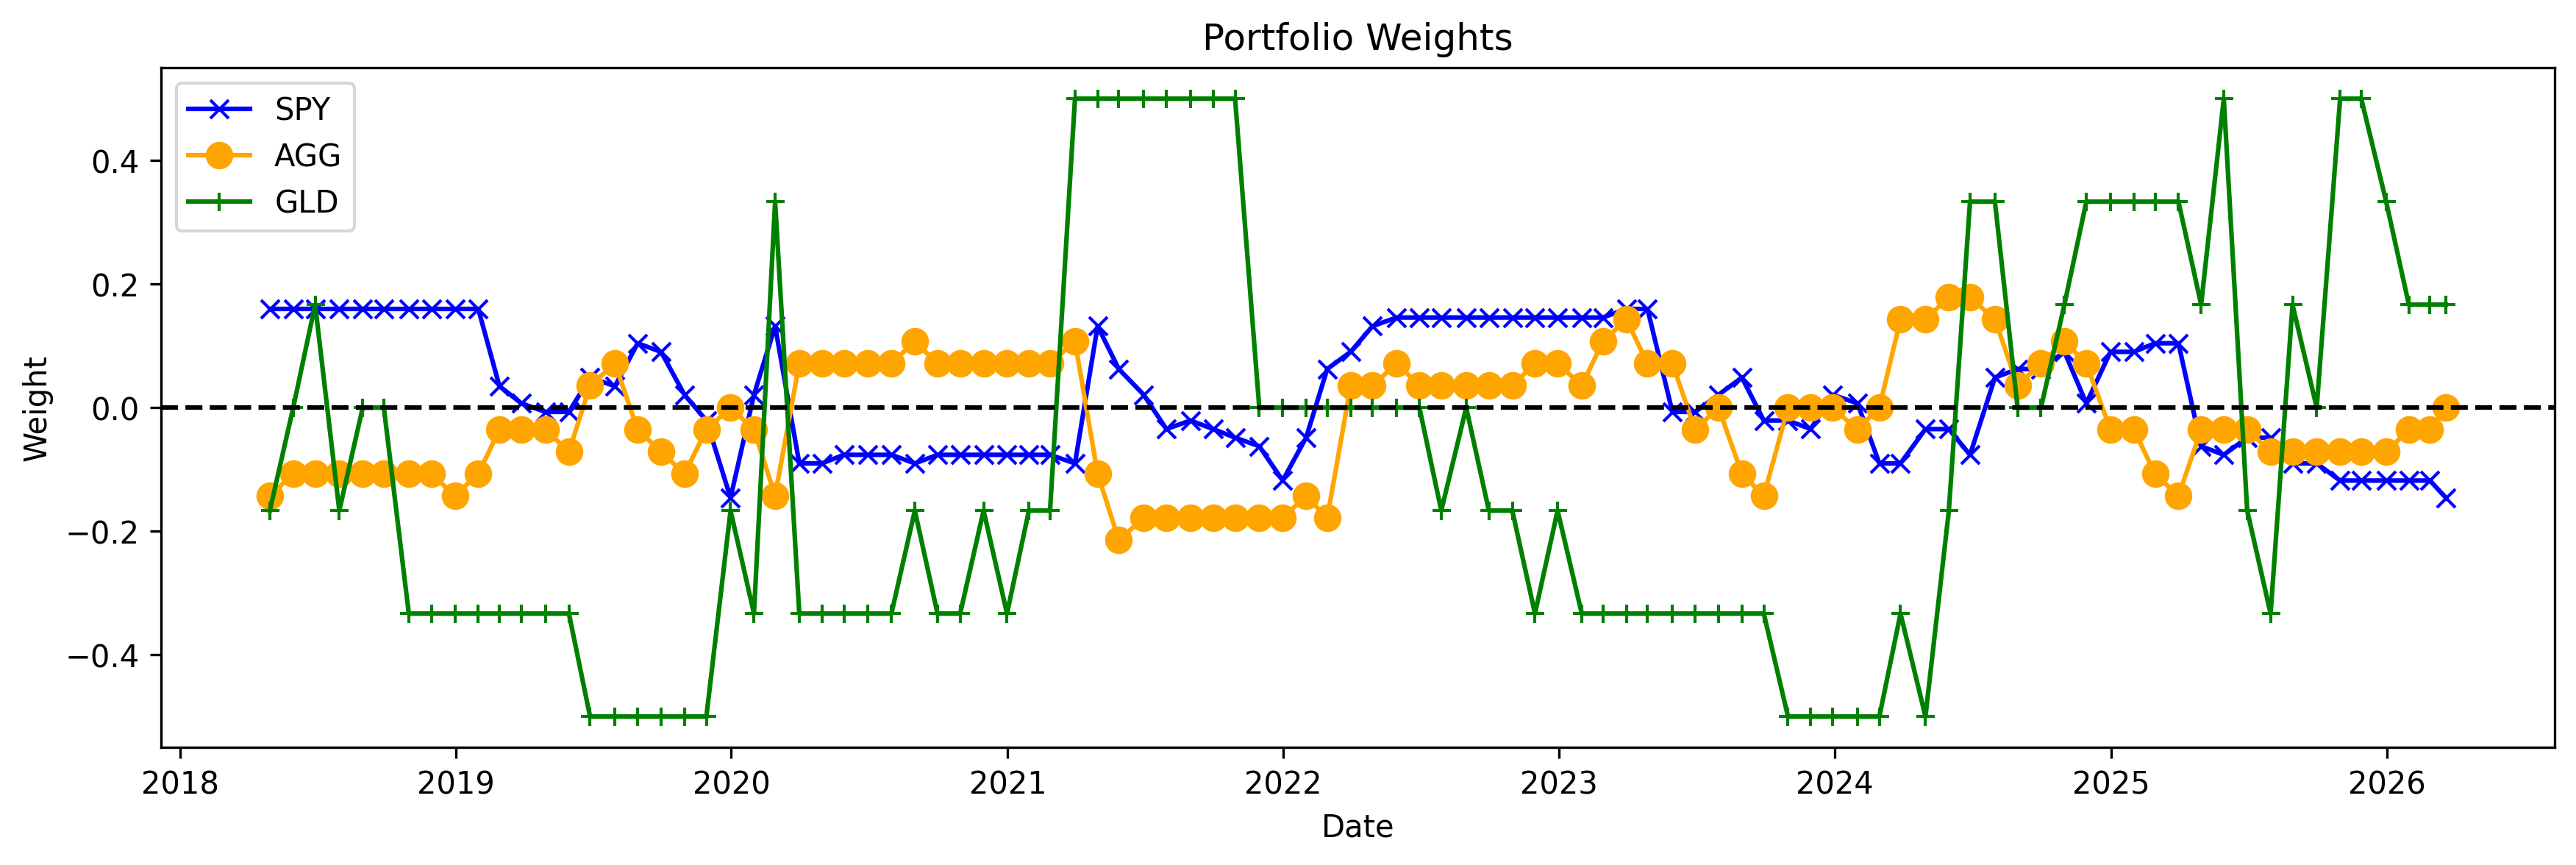

In [16]:
# Filter the data for the three sample assets
spy_data = monthly_vals[monthly_vals['Ticker'] == "SPY"]
agg_data = monthly_vals[monthly_vals['Ticker'] == "AGG"]
gld_data = monthly_vals[monthly_vals['Ticker'] == "GLD"]

plt.figure(figsize=(14, 4), dpi=300)
plt.plot(spy_data['Date'], spy_data['SkewWeight'], label="SPY", color="blue", marker='x', linestyle='-', markersize=6)
plt.plot(agg_data['Date'], agg_data['SkewWeight'], label="AGG", color="orange", marker='o', linestyle='-', markersize=8)
plt.plot(gld_data['Date'], gld_data['SkewWeight'], label="GLD", color="green", marker='+', linestyle='-', markersize=6)
plt.axhline(y=0, color='black', linestyle='--')

plt.title("Portfolio Weights")
plt.xlabel("Date")
plt.ylabel("Weight")
plt.legend()
plt.show()

In [17]:
# Define the forward fill function
def ffill(v):
    # Create a boolean mask where values are non-missing (not NaN)
    mask = ~v.isna()
    # Use accumulate with numpy's maximum to propagate the last valid index
    ffill_indices = np.maximum.accumulate(np.where(mask, np.arange(len(v)), 0))
    # Forward fill by indexing
    return v.iloc[ffill_indices]

# Select relevant columns from monthlyVals and rename NextDate to Date
weightings = monthly_vals[['NextDate', 'Ticker', 'SkewWeight']].rename(columns={'NextDate': 'Date'})

# Perform a left join with the original all_data dataframe
all_data_weights = pd.merge(all_data, weightings, on=['Date', 'Ticker'], how='left')

# Sort by Date
all_data_weights = all_data_weights.sort_values(by='Date')

# Forward fill SkewWeight within each Ticker group
all_data_weights['SkewWeight2'] = all_data_weights.groupby('Ticker')['SkewWeight'].apply(ffill).reset_index(drop=True)

# Ensure the index alignment by resetting the index after the groupby apply operation
all_data_weights['SkewWeight2'] = all_data_weights['SkewWeight2'].values

# Example: Show the first few rows of the result
print(all_data_weights.head())

            Date Ticker      close       open   NextOpen  LogReturn  \
22011 2017-03-30    EWG  23.014530  28.700001  28.660000  -0.005226   
22012 2017-03-30    EWG  23.014530  28.700001  28.660000  -0.005226   
22013 2017-03-31    EWG  23.110996  28.660000  28.790001   0.004183   
22014 2017-03-31    EWG  23.110996  28.660000  28.790001   0.004183   
22015 2017-04-03    EWG  23.078842  28.790001  28.600000  -0.001392   

      AssetClass       Avg       Dev   SkewDay      Skew      Month  \
22011     Equity  0.000709  0.007245 -0.549728  0.127863 2017-03-01   
22012     Equity  0.000752  0.007174 -0.578586  0.131553 2017-03-01   
22013     Equity  0.000778  0.007175  0.106867  0.131996 2017-03-01   
22014     Equity  0.000803  0.007176  0.104475  0.132429 2017-03-01   
22015     Equity  0.000759  0.007154 -0.027187  0.131226 2017-04-01   

            Week    NextDay  SkewWeight  SkewWeight2  
22011 2017-03-27 2017-03-30         NaN          NaN  
22012 2017-03-27 2017-03-31         

### Plotting returns for skew portfolios

In [18]:
# Group by Date and AssetClass, calculate PortfolioReturn and MktReturn
all_data_weights['WeightedReturn'] = all_data_weights['SkewWeightFF'] * all_data_weights['LogReturn']

asset_portfolios = all_data_weights.groupby(['Date', 'AssetClass'], as_index=False).agg(
    ActiveNames=('SkewWeightFF', lambda s: s.notna().sum()),
    PortfolioReturn=('WeightedReturn', lambda s: s.sum(min_count=1)),
    MktReturn=('LogReturn', 'mean')
)

# Remove pre-activation rows (no live positions yet)
asset_portfolios.loc[asset_portfolios['ActiveNames'] == 0, 'PortfolioReturn'] = np.nan
asset_portfolios = asset_portfolios.dropna(subset=['PortfolioReturn', 'MktReturn']).reset_index(drop=True)

asset_portfolios.head()


KeyError: 'SkewWeightFF'

In [ ]:
# Calculate rolling volatility (256-day rolling standard deviation) within each AssetClass
asset_portfolios = asset_portfolios.sort_values(['AssetClass', 'Date']).reset_index(drop=True)
asset_portfolios = asset_portfolios.copy()

asset_portfolios['StratVol'] = asset_portfolios.groupby('AssetClass')['PortfolioReturn'].transform(
    lambda x: x.rolling(window=256, min_periods=256).std()
)
asset_portfolios['MktVol'] = asset_portfolios.groupby('AssetClass')['MktReturn'].transform(
    lambda x: x.rolling(window=256, min_periods=256).std()
)

# Avoid divide-by-near-zero explosions
vol_floor = 1e-6
asset_portfolios['StratVol'] = asset_portfolios['StratVol'].clip(lower=vol_floor)
asset_portfolios['MktVol'] = asset_portfolios['MktVol'].clip(lower=vol_floor)

# Normalize strategy and market by their own volatilities
asset_portfolios['NormReturn'] = 0.1 * asset_portfolios['PortfolioReturn'] / asset_portfolios['StratVol']
asset_portfolios['NormMarketReturn'] = 0.1 * asset_portfolios['MktReturn'] / asset_portfolios['MktVol']

asset_portfolios[['NormReturn', 'NormMarketReturn']] = asset_portfolios[['NormReturn', 'NormMarketReturn']].replace([np.inf, -np.inf], np.nan)

# Group by Date to calculate the global skew factor and global market return
gcf = asset_portfolios.dropna(subset=['NormReturn', 'NormMarketReturn']).groupby('Date').agg(
    Return=pd.NamedAgg(column='NormReturn', aggfunc='mean'),
    MktReturn=pd.NamedAgg(column='NormMarketReturn', aggfunc='mean')
).reset_index()

# Rebase cumulative lines to start at 0 for visual interpretability
gcf['ReturnCum'] = gcf['Return'].cumsum()
gcf['MktReturnCum'] = gcf['MktReturn'].cumsum()
if not gcf.empty:
    gcf['ReturnCum'] = gcf['ReturnCum'] - gcf['ReturnCum'].iloc[0]
    gcf['MktReturnCum'] = gcf['MktReturnCum'] - gcf['MktReturnCum'].iloc[0]

# Plotting the Global Portfolio Returns
plt.figure(figsize=(10, 6))
plt.title("Global Portfolio")

# Plot cumulative Global Skew Factor returns
plt.plot(gcf['Date'], gcf['ReturnCum'], label="Global Skew Factor")

# Plot cumulative Global Market returns
plt.plot(gcf['Date'], gcf['MktReturnCum'], label="Global Market Return")

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='--')

# Add labels and legend
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

# Show the plot
plt.show()


### Alpha vs Beta (vs a mysterious third thing)

In [ ]:
# Set up a 2x3 grid for the plots (adjust based on the number of asset classes)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), dpi=300)

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterate over each asset class and plot the results
for i, asset_class in enumerate(asset_portfolios['AssetClass'].unique()):
    # Filter data for the current asset class
    ac_data = asset_portfolios[asset_portfolios['AssetClass'] == asset_class]
    
    # Plot cumulative returns for the Skew Portfolio
    axes[i].plot(ac_data['Date'], ac_data['PortfolioReturn'].cumsum(), label="Skew Portfolio", color='blue')
    
    # Plot cumulative returns for the Market
    axes[i].plot(ac_data['Date'], ac_data['MktReturn'].cumsum(), label="Market", color='orange')
    
    # Add a horizontal line at y=0
    axes[i].axhline(y=0, color='black', linestyle='--')
    
    # Set the title to the asset class
    axes[i].set_title(asset_class)
    
    # Add labels for the x-axis and y-axis
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Cumulative Return")
    
    # Add a legend
    axes[i].legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

In [ ]:
# Loop over each unique asset class
for ac in asset_portfolios['AssetClass'].unique():
    # Filter the data for the current asset class
    ac_data = asset_portfolios[asset_portfolios['AssetClass'] == ac]
    
    # Define the independent variable (Market Return) and dependent variable (Portfolio Return)
    X = ac_data['MktReturn']
    y = ac_data['PortfolioReturn']
    
    # Add a constant to the independent variable (for the intercept α)
    X = sm.add_constant(X)
    
    # Fit the Ordinary Least Squares (OLS) regression model
    model = sm.OLS(y, X).fit()
    
    # Print the asset class
    print(f"Asset Class: {ac}")
    
    # Print the coefficients (α and β)
    print(model.summary())
    
    # Print the R-squared value
    print(f"R-squared: {model.rsquared}\n")

In [ ]:
# Create an empty DataFrame to store the results
results_table = pd.DataFrame(columns=["Asset Class", "α", "p-value (α)", "β", "p-value (β)", "R²"])

# Loop over each unique asset class
for ac in asset_portfolios['AssetClass'].unique():
    # Filter the data for the current asset class
    ac_data = asset_portfolios[asset_portfolios['AssetClass'] == ac]
    
    # Define the independent variable (Market Return) and dependent variable (Portfolio Return)
    X = ac_data['MktReturn']
    y = ac_data['PortfolioReturn']
    
    # Add a constant to the independent variable (for the intercept α)
    X = sm.add_constant(X)
    
    # Fit the Ordinary Least Squares (OLS) regression model
    model = sm.OLS(y, X).fit()
    
    # Extract the coefficients (α and β), p-values, and R-squared value
    alpha = model.params['const']
    beta = model.params['MktReturn']
    p_value_alpha = model.pvalues['const']
    p_value_beta = model.pvalues['MktReturn']
    r_squared = model.rsquared
    
    # Create a DataFrame for the current result
    result = pd.DataFrame({
        "Asset Class": [ac],
        "α": [round(alpha, 6)],
        "p-value (α)": [round(p_value_alpha, 4)],
        "β": [round(beta, 6)],
        "p-value (β)": [round(p_value_beta, 4)],
        "R²": [round(r_squared, 4)]
    })
    
    # Concatenate the result to the results_table
    results_table = pd.concat([results_table, result], ignore_index=True)

In [ ]:
results_table

### deeper dive into more equity factors

In [ ]:
# Load data for each factor ETF
mtum = load("MTUM")  # Momentum
vtv = load("VTV")    # Value
vug = load("VUG")    # Growth
cry = load("VIG")    # Carry

# Concatenate the DataFrames into a single DataFrame
equity_factors = pd.concat([mtum, vtv, vug, cry], ignore_index=True)

# Optional: Display the first few rows to verify
print(equity_factors.head())

In [ ]:
# Filter the equity data from asset_portfolios
equity = asset_portfolios[asset_portfolios['AssetClass'] == "Equity"]

# Ensure the Date columns are in datetime format
equity['Date'] = pd.to_datetime(equity['Date'])
equity_factors['Date'] = pd.to_datetime(equity_factors['Date'])

# Unstack the equityFactors data
equity_factors_unstacked = equity_factors.pivot(index='Date', columns='Ticker', values='LogReturn')

# Join the unstacked equityFactors with the equity data on the Date column
equity = pd.merge(equity, equity_factors_unstacked, on='Date', how='left')

# Rename the columns to match the factor names
equity.rename(columns={
    'MTUM': 'MTUM',  # Assuming the ticker MTUM represents momentum
    'VTV': 'VTV',    # Value
    'VUG': 'VUG',    # Growth
    'VIG': 'VIG'     # Carry
}, inplace=True)

# Prepare the independent variables (MktReturn and factor returns) and dependent variable (PortfolioReturn)
X = equity[['MktReturn', 'MTUM', 'VTV', 'VUG', 'VIG']]
y = equity['PortfolioReturn']

# Add a constant to the independent variables (for the intercept)
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X).fit()

# Display the regression coefficients table
print(model.summary())

In [ ]:
# Filter the equity data from asset_portfolios
equity = asset_portfolios[asset_portfolios['AssetClass'] == "Equity"]

# Ensure the Date columns are in datetime format
equity['Date'] = pd.to_datetime(equity['Date'])
equity_factors['Date'] = pd.to_datetime(equity_factors['Date'])

# Unstack the equityFactors data
equity_factors_unstacked = equity_factors.pivot(index='Date', columns='Ticker', values='LogReturn')

# Join the unstacked equityFactors with the equity data on the Date column
equity = pd.merge(equity, equity_factors_unstacked, on='Date', how='left')

# Rename the columns to match the factor names
equity.rename(columns={
    'MTUM': 'MTUM',  # Assuming the ticker MTUM represents momentum
    'VTV': 'VTV',    # Value
    'VUG': 'VUG',    # Growth
    'VIG': 'VIG'     # Carry
}, inplace=True)

# Prepare the independent variables (MktReturn and factor returns) and dependent variable (PortfolioReturn)
X = equity[['MktReturn', 'MTUM', 'VTV', 'VUG', 'VIG']]
y = equity['PortfolioReturn']

# Add a constant to the independent variables (for the intercept)
X = sm.add_constant(X)

# Fit the OLS regression model
model = sm.OLS(y, X).fit()

# Extract the results and create a DataFrame
results_df = pd.DataFrame({
    "Coef.": model.params,
    "Std. Error": model.bse,
    "t": model.tvalues,
    "Pr(>|t|)": model.pvalues,
    "Lower 95%": model.conf_int()[0],
    "Upper 95%": model.conf_int()[1]
})

# Formatting the DataFrame for better display
results_df = results_df.round(6)

In [ ]:
results_df